In [41]:
import essentia.standard as es
import numpy as np
import subprocess
import numpy as np
from PIL import Image
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import itertools
import essentia
import numpy as np

import cProfile
import pstats

import IPython.display as ipd
import essentia.standard as es
import matplotlib.pyplot as plt

from datetime import datetime

In [43]:
from helpers import (
    load_and_detect_onsets,
    plot_waveform_with_onsets
)

In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
from IPython.display import HTML
audio_style = "<style>audio { margin-left: 23px; width: 720px; }</style>"
display(HTML(audio_style))

In [46]:
from ck_helpers import (
    load_audio_as_spectrogram_essentia,
    compute_ck1_distance,
    compute_spectrogram_from_chunk,
    analyze_recording_onsets_ck,
)

---

In [47]:
df = None
print("Found metadata sources:")
for csv_path in glob.glob(os.path.join("../data/meta", "dataset_*.csv")):
    print(csv_path)

    # figure out the used query based on the query metadata file
    json_path = csv_path[:csv_path.rfind(".")] + ".json"
    with open(json_path, "r") as f:
        query_data = json.load(f)
        
    raw_query = query_data.get("query", "")
    
    # 1. Split at the first " -" to drop all exclusions, and strip any trailing whitespace
    clean_query = raw_query.split(" -")[0].strip()
    
    # 2. Swap double quotes for single quotes to prevent ugly CSV triple-quoting
    # '"3 times"' becomes "'3 times'", 'dog barking' remains 'dog barking'
    clean_query = clean_query.replace('"', "'")
    
    if df is None:
        df = pd.read_csv(csv_path)
        df["search_query"] = clean_query
    else:
        local_df = pd.read_csv(csv_path)
        local_df["search_query"] = clean_query
        df = pd.concat([df, local_df], ignore_index=True)

df = df.drop_duplicates(subset=['sound_id'], keep='first').reset_index(drop=True)

Found metadata sources:
../data/meta/dataset_2026-06-15_14-36-36.csv
../data/meta/dataset_2026-05-20_14-27-00.csv
../data/meta/dataset_2026-06-02_15-32-39.csv
../data/meta/dataset_2026-06-02_16-15-49.csv
../data/meta/dataset_2026-06-12_18-50-48.csv
../data/meta/dataset_2026-06-15_15-18-42.csv
../data/meta/dataset_2026-06-02_18-16-48.csv
../data/meta/dataset_2026-06-13_16-52-26.csv
../data/meta/dataset_2026-06-02_16-24-32.csv
../data/meta/dataset_2026-06-14_09-39-52.csv
../data/meta/dataset_2026-06-13_17-47-59.csv
../data/meta/dataset_2026-06-02_17-59-57.csv
../data/meta/dataset_2026-06-02_17-13-17.csv
../data/meta/dataset_2026-05-23_14-14-52.csv
../data/meta/dataset_2026-06-12_18-26-39.csv
../data/meta/dataset_2026-05-23_14-36-27.csv
../data/meta/dataset_2026-06-02_17-08-15.csv
../data/meta/dataset_2026-06-02_16-21-22.csv
../data/meta/dataset_2026-05-23_14-36-09.csv
../data/meta/dataset_2026-06-12_18-54-51.csv
../data/meta/dataset_2026-06-02_15-40-15.csv
../data/meta/dataset_2026-06-12

In [48]:
with open("../data/annotations5.json", "r") as f:
    annotations = json.load(f)

In [51]:
from pprint import pp
pp(annotations)

{'655124': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.5340589284896851,
                                       2.2639455795288086,
                                       3.8196825981140137]},
 '722978': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.18575963377952576,
                                       0.847528338432312,
                                       1.5092970132827759]},
 '765153': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.743038535118103,
                                       3.3785033226013184,
                                       5.398639678955078]},
 '233665': {'repetitive_onset_indices': [0, 1, 2, 3, 4],
            'repetitive_onset_times': [0.02321995422244072,
                                       0.27863946557044983,
                                       0.41795918345451355,
                                       0.5921088457107544,
                

Index 895, annotating sound with id: 682768


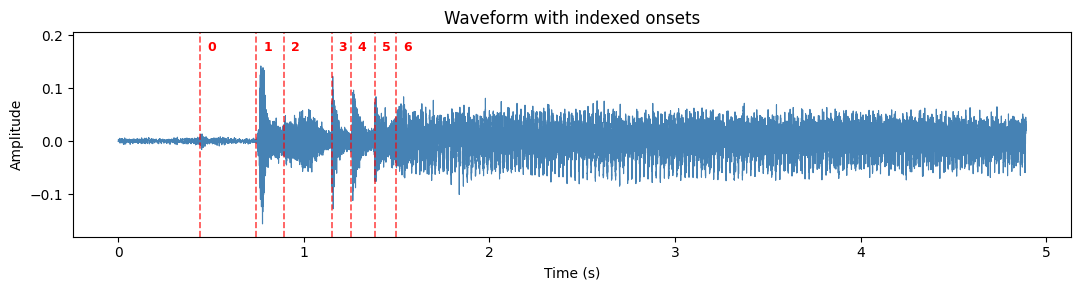

In [145]:
i = list(df["sound_id"]).index(682768)
path = df.iloc[i]["local_path"]
sound_id = df.iloc[i]["sound_id"]
print(f"Index {i}, annotating sound with id: {sound_id}")
audio, onsets = load_and_detect_onsets(path)
plot_waveform_with_onsets(audio, onsets, show_spectrogram=False)
ipd.display(ipd.Audio(audio, rate=16000))

### Pairwise CK-1 distance matrices for repetitive sound onsets

Microwave beeps: the "easiest", sanity-check example

In [243]:
i = list(df["sound_id"]).index(232929)
i

601

Index 601, annotating sound with id: 232929


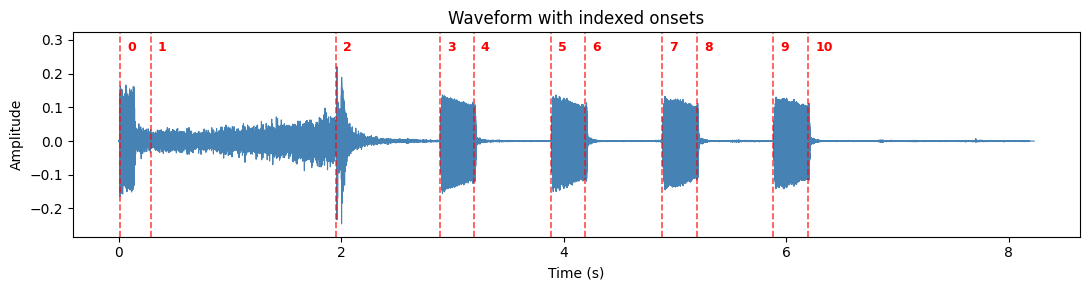

In [244]:
path = df.iloc[i]["local_path"]
sound_id = df.iloc[i]["sound_id"]
print(f"Index {i}, annotating sound with id: {sound_id}")
audio, onsets = load_and_detect_onsets(path)
plot_waveform_with_onsets(audio, onsets, show_spectrogram=False)
ipd.display(ipd.Audio(audio, rate=16000))

Processing: 232929_4211564-hq.ogg
Filtered Onsets to process: 11
Successfully generated 11 onset spectrograms.
[[0.         0.7826087  0.77929155 0.63178914 0.77924362 0.65275591
  0.78659612 0.67955801 0.78488889 0.69606299 0.7875    ]
 [0.7826087  0.         0.75392157 0.80187874 0.80397727 0.81328848
  0.80911681 0.80522766 0.7940613  0.82169891 0.79788258]
 [0.77929155 0.75392157 0.         0.79708826 0.79979675 0.80483438
  0.80632008 0.79084381 0.78806584 0.80931065 0.79007239]
 [0.63178914 0.80187874 0.79708826 0.         0.74449339 0.3785489
  0.74734982 0.42687747 0.730187   0.42350158 0.72271914]
 [0.77924362 0.80397727 0.79979675 0.74449339 0.         0.75455334
  0.53785644 0.7        0.56349206 0.75021683 0.55433699]
 [0.65275591 0.81328848 0.80483438 0.3785489  0.75455334 0.
  0.74956522 0.416212   0.75985977 0.40902022 0.72975352]
 [0.78659612 0.80911681 0.80632008 0.74734982 0.53785644 0.74956522
  0.         0.74106364 0.51343284 0.75391304 0.447     ]
 [0.67955801 0.8

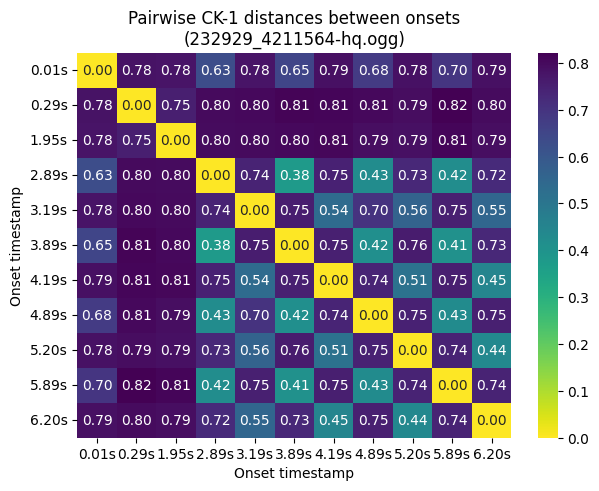

In [245]:
sample_row = df.iloc[i] 
file_path = sample_row['local_path']

# Run the experimental pipeline
matrix_microwave, onsets, _ = analyze_recording_onsets_ck(file_path, window_ms=125, log_freq=True)
print(matrix_microwave)

# Plot the matrix as a heatmap
if matrix_microwave is not None:
    plt.figure(figsize=(7,5))
    sns.heatmap(
        matrix_microwave, 
        cmap="viridis_r", # Reversed viridis: darker colors mean closer to 0 (highly similar)
        xticklabels=[f"{t:.2f}s" for t in onsets],
        yticklabels=[f"{t:.2f}s" for t in onsets],
        annot=True,       # Displays raw CK values in the boxes if onset count is small
        fmt=".2f"
    )
    plt.title(f"Pairwise CK-1 distances between onsets\n({os.path.basename(file_path)})")
    plt.xlabel("Onset timestamp")
    plt.ylabel("Onset timestamp")
    plt.show()

Northern Raven caws: a type of animal call sound used in the paper

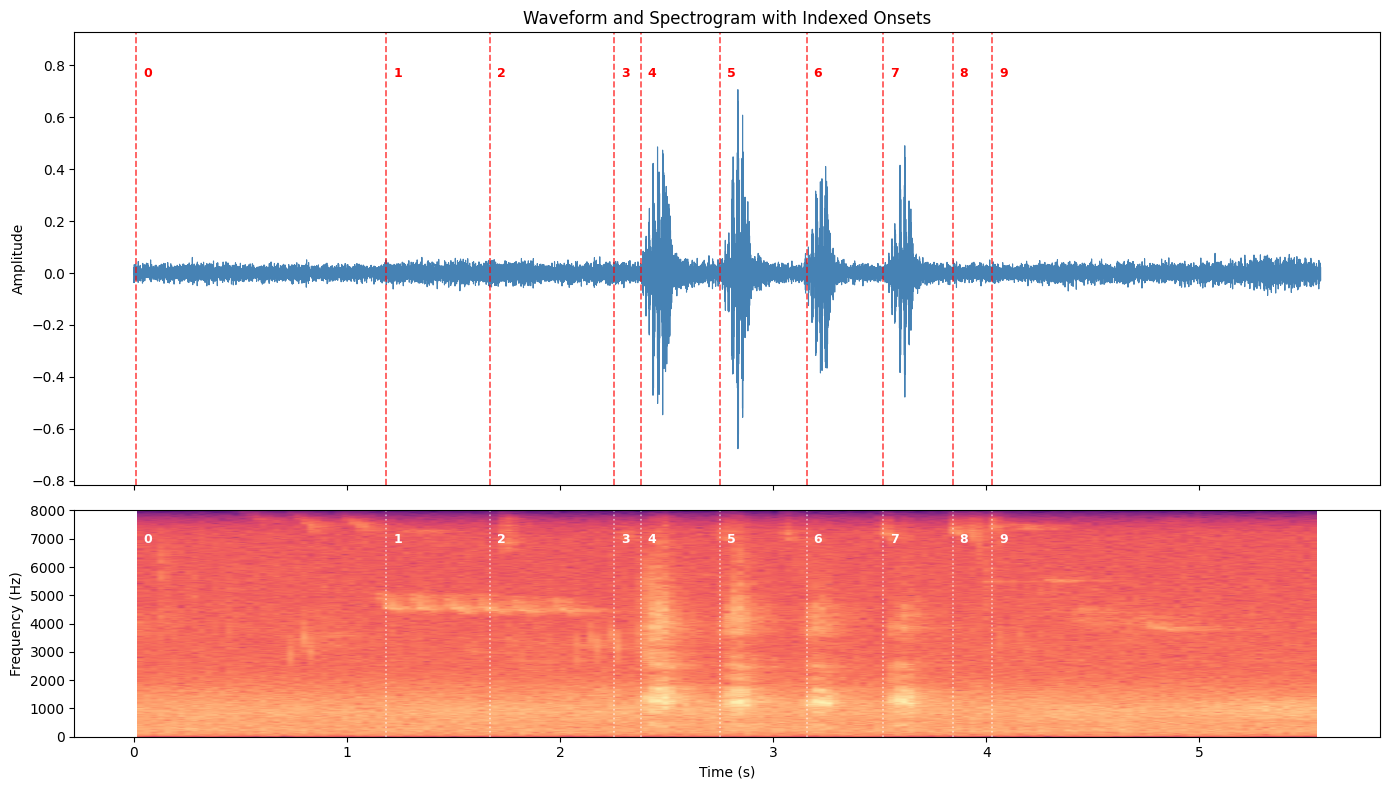

In [246]:
audio, onsets = load_and_detect_onsets("../data/xc/XC1089337 - Northern Raven - Corvus corax.wav")
plot_waveform_with_onsets(audio, onsets, show_spectrogram=True)
ipd.Audio(audio, rate=16000)

Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfully generated 10 onset spectrograms.
[[0.         0.58971963 0.62488307 0.62156863 0.73987854 0.71198389
  0.65873837 0.71270161 0.6419295  0.59490085]
 [0.58971963 0.         0.61353517 0.65456238 0.74088292 0.71728749
  0.7208619  0.73040153 0.66607774 0.60377358]
 [0.62488307 0.61353517 0.         0.63932898 0.75792507 0.74378585
  0.72254902 0.73779904 0.67374005 0.69604317]
 [0.62156863 0.65456238 0.63932898 0.         0.7328629  0.73821464
  0.69721936 0.70582329 0.64879852 0.6519285 ]
 [0.73987854 0.74088292 0.75792507 0.7328629  0.         0.63626943
  0.59211928 0.61514523 0.76571429 0.74684772]
 [0.71198389 0.71728749 0.74378585 0.73821464 0.63626943 0.
  0.60699153 0.53044376 0.75260664 0.7519305 ]
 [0.65873837 0.7208619  0.72254902 0.69721936 0.59211928 0.60699153
  0.         0.55779427 0.71234208 0.72574257]
 [0.71270161 0.73040153 0.73779904 0.70582329 0.61514523 0.53044376


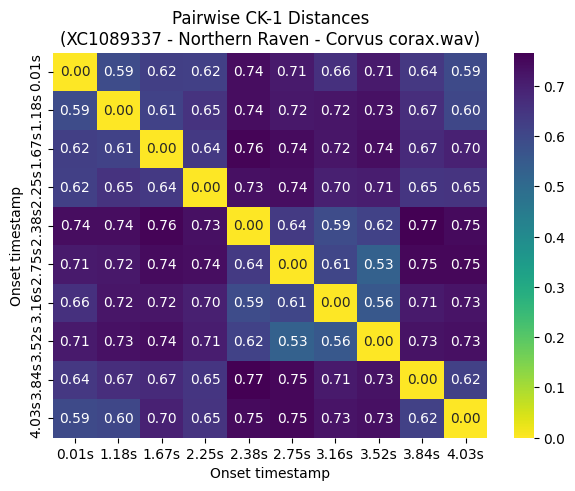

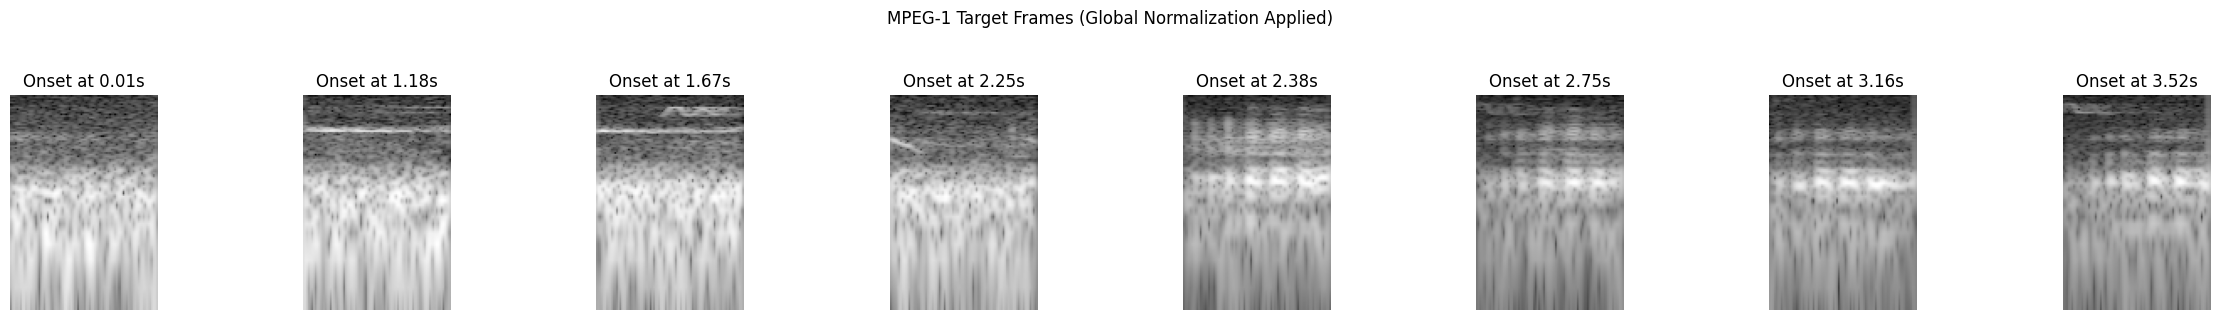

In [248]:
file_path = "../data/xc/XC1089337 - Northern Raven - Corvus corax.wav"

matrix_raven, onsets, specs = analyze_recording_onsets_ck(file_path, window_ms=125, log_freq=True)
print(matrix_raven)

if matrix_raven is not None and specs is not None:
    # ---------------------------------------------------------
    # PLOT 1: The Distance Matrix
    # ---------------------------------------------------------
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matrix_raven, 
        cmap="viridis_r", 
        xticklabels=[f"{t:.2f}s" for t in onsets],
        yticklabels=[f"{t:.2f}s" for t in onsets],
        annot=True,       
        fmt=".2f"
    )
    plt.title(f"Pairwise CK-1 Distances\n({os.path.basename(file_path)})")
    plt.xlabel("Onset timestamp")
    plt.ylabel("Onset timestamp")
    plt.show()

    # ---------------------------------------------------------
    # PLOT 2: The Spectrogram Chunks (What MPEG-1 actually sees)
    # ---------------------------------------------------------
    # We will plot up to the first 8 onsets so the screen doesn't get too crowded
    num_to_plot = min(len(specs), 8)
    fig, axes = plt.subplots(1, num_to_plot, figsize=(3 * num_to_plot, 3))
    
    # Handle the case where there's only 1 row/column to plot
    if num_to_plot == 1:
        axes = [axes]
        
    for i in range(num_to_plot):
        # origin='lower' ensures low frequencies are at the bottom!
        axes[i].imshow(specs[i], cmap='gray', origin='lower')
        axes[i].set_title(f"Onset at {onsets[i]:.2f}s")
        axes[i].axis('off')
        
    plt.suptitle("MPEG-1 Target Frames (Global Normalization Applied)", y=1.05)
    plt.tight_layout()
    plt.show()

Lar Gibbon sound: another example mentioned in the cited paper

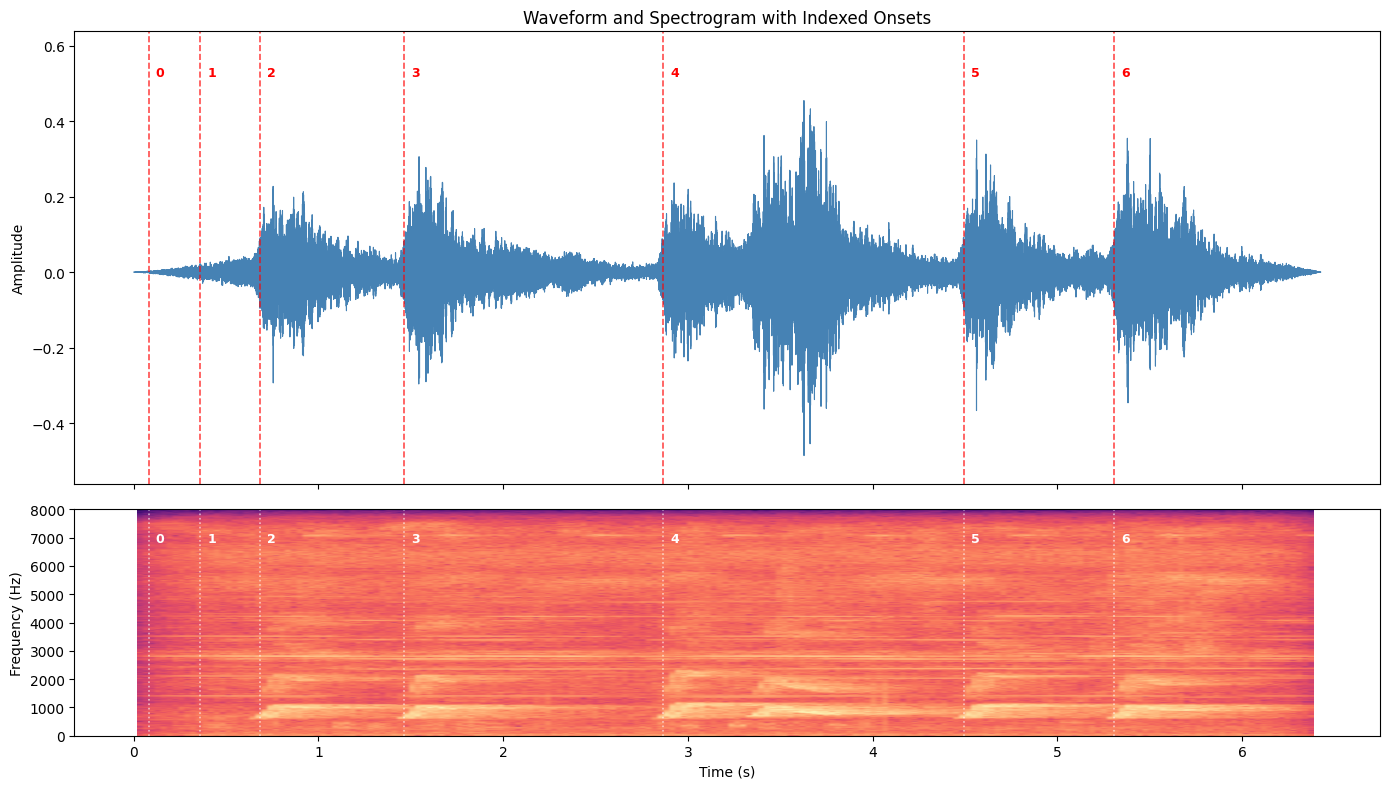

In [249]:
audio, onsets = load_and_detect_onsets("../data/xc/XC1155322 - Lar Gibbon - Hylobates lar.wav")
plot_waveform_with_onsets(audio, onsets, show_spectrogram=True)
ipd.Audio(audio, rate=16000)

Processing: XC1155322 - Lar Gibbon - Hylobates lar.wav
Filtered Onsets to process: 7
Successfully generated 7 onset spectrograms.
[[0.         0.73706897 0.70588235 0.75037594 0.76259542 0.77484472
  0.7822327 ]
 [0.73706897 0.         0.79402262 0.81705298 0.7962963  0.81560892
  0.77652174]
 [0.70588235 0.79402262 0.         0.54676871 0.566609   0.49911817
  0.58318426]
 [0.75037594 0.81705298 0.54676871 0.         0.59591474 0.51992754
  0.53584559]
 [0.76259542 0.7962963  0.566609   0.59591474 0.         0.54889299
  0.62734082]
 [0.77484472 0.81560892 0.49911817 0.51992754 0.54889299 0.
  0.56022945]
 [0.7822327  0.77652174 0.58318426 0.53584559 0.62734082 0.56022945
  0.        ]]


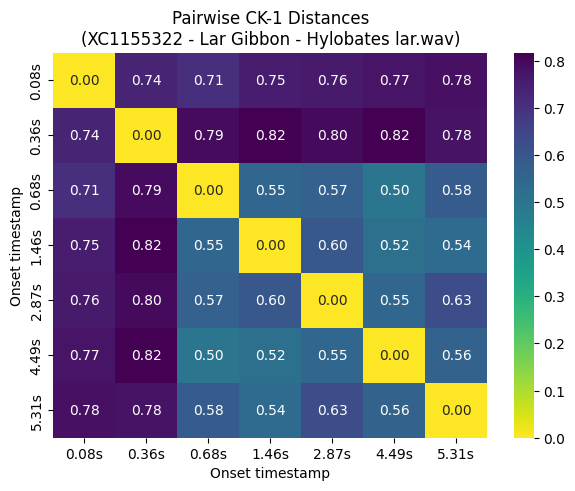

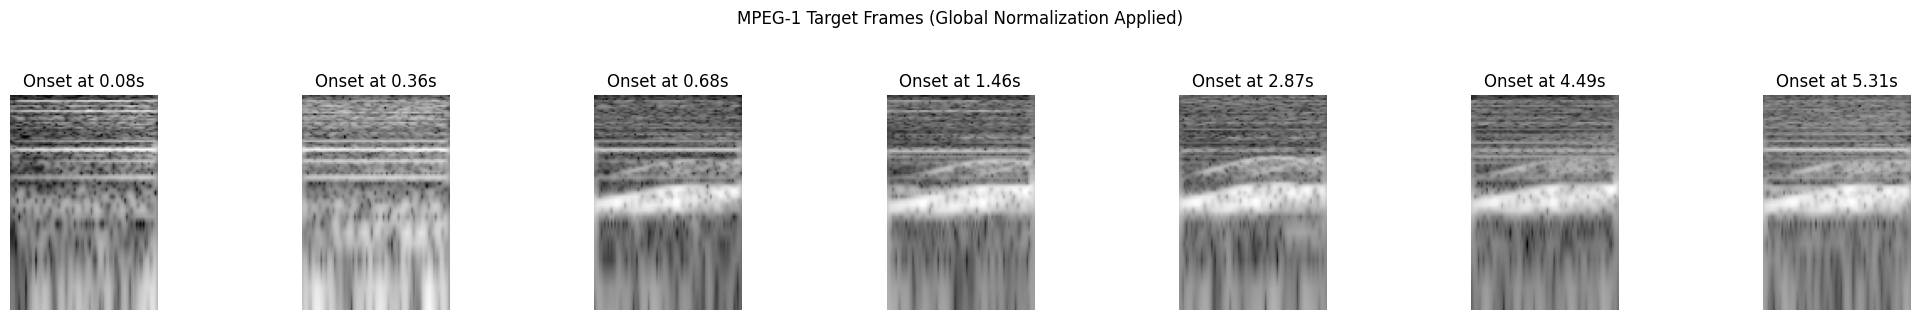

In [250]:
file_path = "../data/xc/XC1155322 - Lar Gibbon - Hylobates lar.wav"

matrix_gibbon, onsets, specs = analyze_recording_onsets_ck(file_path, window_ms=125, log_freq=True)
print(matrix_gibbon)

if matrix_gibbon is not None and specs is not None:
    # ---------------------------------------------------------
    # PLOT 1: The Distance Matrix
    # ---------------------------------------------------------
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matrix_gibbon, 
        cmap="viridis_r", 
        xticklabels=[f"{t:.2f}s" for t in onsets],
        yticklabels=[f"{t:.2f}s" for t in onsets],
        annot=True,       
        fmt=".2f"
    )
    plt.title(f"Pairwise CK-1 Distances\n({os.path.basename(file_path)})")
    plt.xlabel("Onset timestamp")
    plt.ylabel("Onset timestamp")
    plt.show()

    # ---------------------------------------------------------
    # PLOT 2: The Spectrogram Chunks (What MPEG-1 actually sees)
    # ---------------------------------------------------------
    # We will plot up to the first 8 onsets so the screen doesn't get too crowded
    num_to_plot = min(len(specs), 8)
    fig, axes = plt.subplots(1, num_to_plot, figsize=(3 * num_to_plot, 3))
    
    # Handle the case where there's only 1 row/column to plot
    if num_to_plot == 1:
        axes = [axes]
        
    for i in range(num_to_plot):
        # origin='lower' ensures low frequencies are at the bottom!
        axes[i].imshow(specs[i], cmap='gray', origin='lower')
        axes[i].set_title(f"Onset at {onsets[i]:.2f}s")
        axes[i].axis('off')
        
    plt.suptitle("MPEG-1 Target Frames (Global Normalization Applied)", y=1.05)
    plt.tight_layout()
    plt.show()

Combined raven and gibbon recording: in order to examine similarity intra-cluster and outside a cluster

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


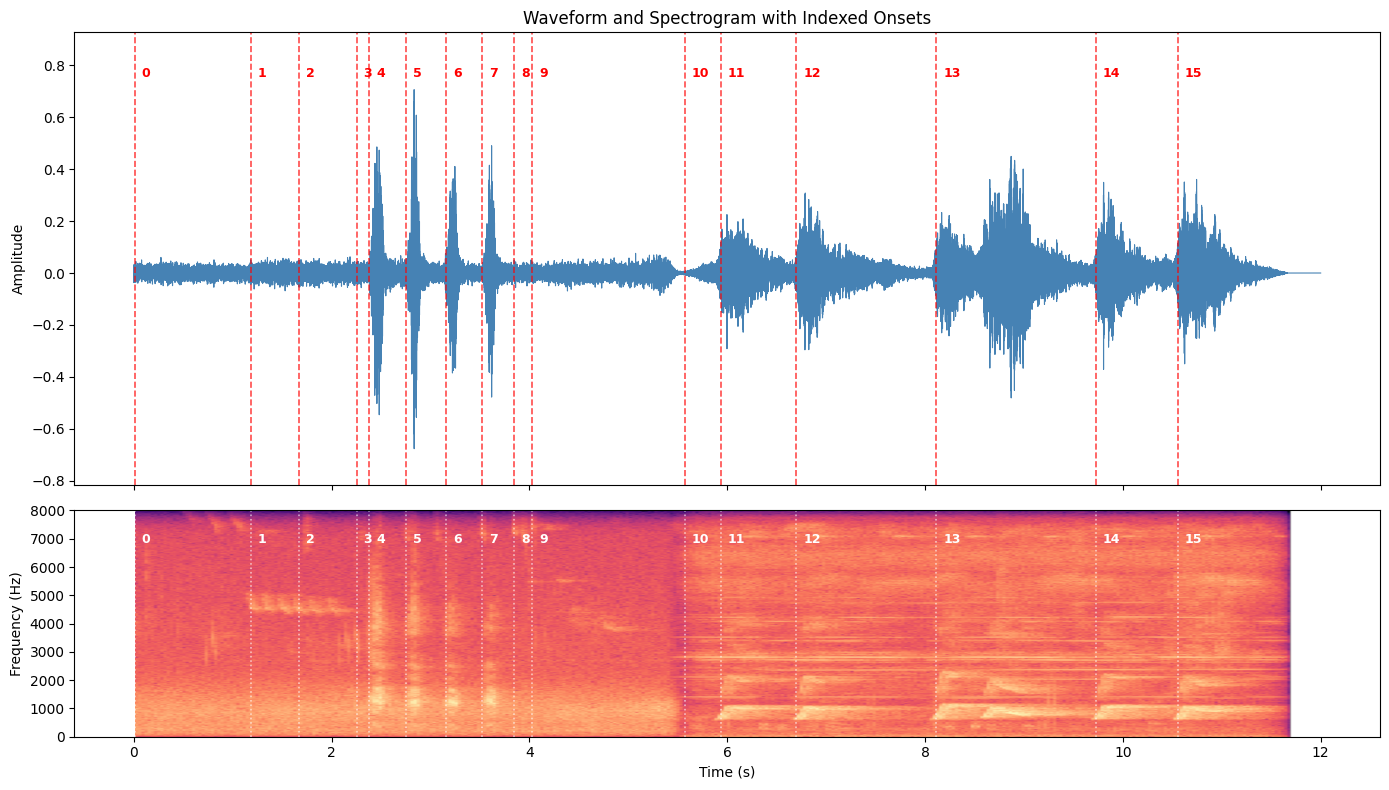

In [251]:
audio, onsets = load_and_detect_onsets("../data/xc/combined.wav")
plot_waveform_with_onsets(audio, onsets, show_spectrogram=True)
ipd.Audio(audio, rate=16000)

Processing: combined.wav
Filtered Onsets to process: 16
Successfully generated 16 onset spectrograms.
[[0.         0.61850803 0.62921348 0.61606268 0.74673367 0.72261307
  0.66735537 0.71601208 0.64206642 0.60113422 0.79655172 0.7740113
  0.76923077 0.77070064 0.78195489 0.77942539]
 [0.61850803 0.         0.62511292 0.65377358 0.74758221 0.72920696
  0.71400199 0.74418605 0.65360641 0.60619872 0.80650542 0.77838329
  0.78205128 0.78910369 0.77606528 0.77728086]
 [0.62921348 0.62511292 0.         0.63049579 0.75551294 0.74784276
  0.72637795 0.73679155 0.66431095 0.68444846 0.80215232 0.79279279
  0.78655767 0.79337402 0.78507194 0.78793256]
 [0.61606268 0.65377358 0.63049579 0.         0.72188755 0.71987952
  0.69349845 0.71428571 0.62764977 0.65627951 0.78294574 0.74035748
  0.74857685 0.76272727 0.77183099 0.75555556]
 [0.74673367 0.74758221 0.75551294 0.72188755 0.         0.59690722
  0.57900318 0.62809917 0.75826251 0.76669894 0.77885463 0.77338476
  0.76264591 0.77653631 0.77959

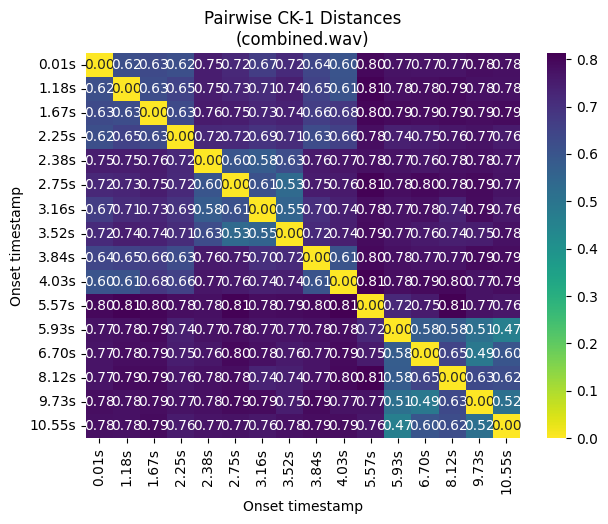

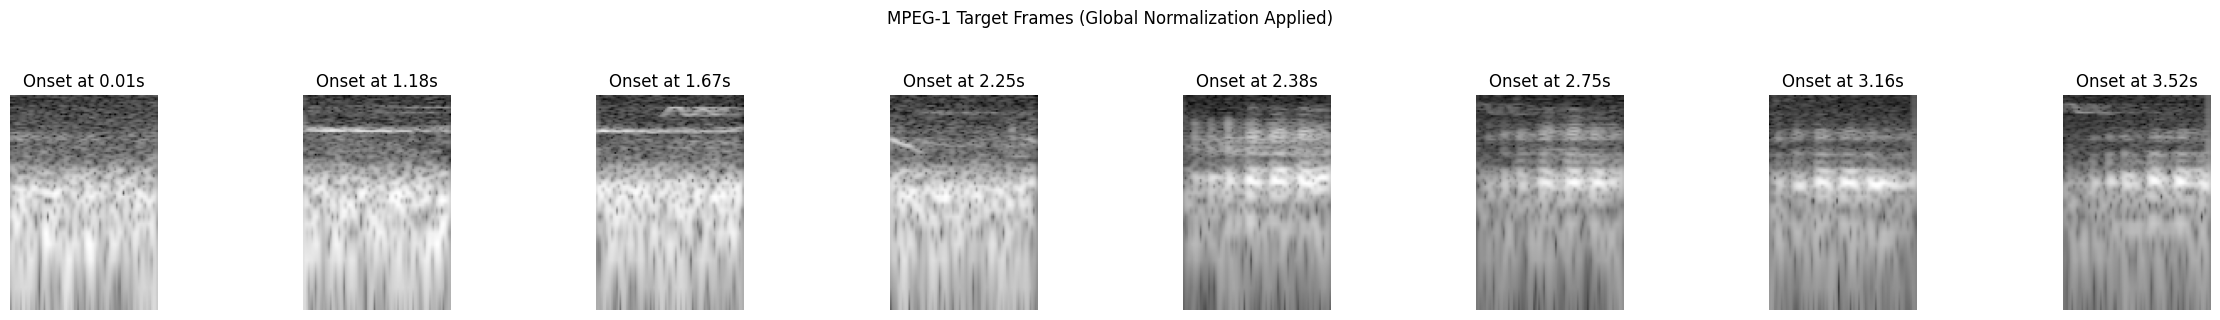

In [252]:
file_path = "../data/xc/combined.wav"
matrix_combined, onsets, specs = analyze_recording_onsets_ck(file_path, window_ms=125, log_freq=True)
print(matrix_combined)

if matrix_combined is not None and specs is not None:
    # ---------------------------------------------------------
    # PLOT 1: The Distance Matrix
    # ---------------------------------------------------------
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matrix_combined, 
        cmap="viridis_r", 
        xticklabels=[f"{t:.2f}s" for t in onsets],
        yticklabels=[f"{t:.2f}s" for t in onsets],
        annot=True,       
        fmt=".2f"
    )
    plt.title(f"Pairwise CK-1 Distances\n({os.path.basename(file_path)})")
    plt.xlabel("Onset timestamp")
    plt.ylabel("Onset timestamp")
    plt.show()

    # ---------------------------------------------------------
    # PLOT 2: The Spectrogram Chunks (What MPEG-1 actually sees)
    # ---------------------------------------------------------
    # We will plot up to the first 8 onsets so the screen doesn't get too crowded
    num_to_plot = min(len(specs), 8)
    fig, axes = plt.subplots(1, num_to_plot, figsize=(3 * num_to_plot, 3))
    
    # Handle the case where there's only 1 row/column to plot
    if num_to_plot == 1:
        axes = [axes]
        
    for i in range(num_to_plot):
        # origin='lower' ensures low frequencies are at the bottom!
        axes[i].imshow(specs[i], cmap='gray', origin='lower')
        axes[i].set_title(f"Onset at {onsets[i]:.2f}s")
        axes[i].axis('off')
        
    plt.suptitle("MPEG-1 Target Frames (Global Normalization Applied)", y=1.05)
    plt.tight_layout()
    plt.show()

In [20]:
!ls ../data/xc

'XC1042650 - Northern Raven - Corvus corax.wav'
'XC1089337 - Northern Raven - Corvus corax.wav'
'XC1155322 - Lar Gibbon - Hylobates lar.wav'
'XC15628 - Santa Marta Brushfinch - Atlapetes melanocephalus.mp3'
'XC219206 - Chestnut-capped Brushfinch - Arremon brunneinucha.mp3'
'XC317022 - Common Chaffinch - Fringilla coelebs.mp3'
'XC636421 - Northern Raven - Corvus corax.mp3'
'XC959730 - Eastern Gray Gibbon - Hylobates funereus.mp3'
'XC960736 - Pileated Gibbon - Hylobates pileatus.mp3'
 combined.wav


### Implementation improvement loop

In [207]:
from ck_eval import evaluate

In [208]:
labels_microwave = [[3, 5, 7, 9]]
labels_raven = [[4, 5, 6, 7]]
labels_gibbon = [[2, 3, 5, 6]]
labels_combined = [[4, 5, 6, 7], [11, 12, 14, 15]]

In [209]:
mw_path = "../data/audio/microwave-beeps/232929_4211564-hq.ogg"
rv_path = "../data/xc/XC1089337 - Northern Raven - Corvus corax.wav"
gb_path = "../data/xc/XC1155322 - Lar Gibbon - Hylobates lar.wav"
cb_path = "../data/xc/combined.wav"

In [210]:
%%time
matrix_microwave, _, specs_mw = analyze_recording_onsets_ck("../data/audio/microwave-beeps/232929_4211564-hq.ogg", window_ms=125)
matrix_raven, _, specs_rv = analyze_recording_onsets_ck("../data/xc/XC1089337 - Northern Raven - Corvus corax.wav", window_ms=125)
matrix_gibbon, _, specs_gb = analyze_recording_onsets_ck("../data/xc/XC1155322 - Lar Gibbon - Hylobates lar.wav", window_ms=125)
matrix_combined, _, specs_cb = analyze_recording_onsets_ck("../data/xc/combined.wav", window_ms=125)

Processing: 232929_4211564-hq.ogg
Filtered Onsets to process: 11
Successfully generated 11 onset spectrograms.
Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfully generated 10 onset spectrograms.
Processing: XC1155322 - Lar Gibbon - Hylobates lar.wav
Filtered Onsets to process: 7
Successfully generated 7 onset spectrograms.
Processing: combined.wav
Filtered Onsets to process: 16
Successfully generated 16 onset spectrograms.
CPU times: user 2.75 s, sys: 478 ms, total: 3.22 s
Wall time: 1min 22s


In [211]:
print(evaluate(matrix_microwave, labels_microwave, "microwave"), "\n")
print(evaluate(matrix_raven, labels_raven, "raven"), "\n")
print(evaluate(matrix_gibbon, labels_gibbon, "gibbon"), "\n")
print(evaluate(matrix_combined, labels_combined, "combined"), "\n")

{'name': 'microwave', 'n_onsets': 11, 'n_pos_pairs': 6, 'n_neg_pairs': 49, 'auc': np.float64(1.0), 'auc_ci95': (np.float64(1.0), np.float64(1.0)), 'map': 1.0, 'nn1': 1.0, 'motif_top1': True, 'median_within': 0.3032455148779153, 'median_between': 0.7918552036199096, 'range_all': (0.289407313997478, 0.849182763744428)} 

{'name': 'raven', 'n_onsets': 10, 'n_pos_pairs': 6, 'n_neg_pairs': 39, 'auc': np.float64(0.9957264957264957), 'auc_ci95': (np.float64(0.9567567567567568), np.float64(1.0)), 'map': 1.0, 'nn1': 1.0, 'motif_top1': True, 'median_within': 0.6221629447730164, 'median_between': 0.750445632798574, 'range_all': (0.5825049701789264, 0.7834782608695652)} 

{'name': 'gibbon', 'n_onsets': 7, 'n_pos_pairs': 6, 'n_neg_pairs': 15, 'auc': np.float64(1.0), 'auc_ci95': (np.float64(1.0), np.float64(1.0)), 'map': 1.0, 'nn1': 1.0, 'motif_top1': True, 'median_within': 0.5564588837989817, 'median_between': 0.7368789363191042, 'range_all': (0.5229276895943562, 0.7835218093699516)} 

{'name': 'co

In [212]:
matrix_raven, _, specs_raven = analyze_recording_onsets_ck("../data/xc/XC1089337 - Northern Raven - Corvus corax.wav", window_ms=125)

Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfully generated 10 onset spectrograms.


In [253]:
"""Quick visual inspection of onset spectrograms."""

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def _preprocess(spec, target_size=(256, 256)):
    """
    Mirror of the nested preprocess_spectrogram() inside compute_ck1_distance.
    Kept in sync manually -- if you change the normalization there, change it
    here too, or this plot stops showing what ffmpeg actually sees.
    """
    s_min, s_max = spec.min(), spec.max()
    if s_max > s_min:
        norm = 255.0 * (spec - s_min) / (s_max - s_min)
    else:
        norm = np.zeros_like(spec)
    img = Image.fromarray(norm.astype(np.uint8))
    return np.array(img.resize(target_size, Image.Resampling.BILINEAR))


def plot_spectrogram_grid(specs, groups=None, times=None, as_sent=True,
                          ncols=5, target_size=(256, 256), cmap="magma",
                          title=None):
    """
    specs   : list of 2D spectrogram arrays (freq x time), one per onset
    groups  : optional list of index lists, e.g. [[4,5,6,7], [11,12,14,15]]
              members get a coloured border and a group tag
    times   : optional onset timestamps, shown in the label
    as_sent : True  -> show the normalized, resized uint8 image ffmpeg encodes
              False -> show the raw dB spectrogram
    """
    n = len(specs)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    member = {}
    if groups:
        for gid, g in enumerate(groups):
            for i in g:
                member[i] = gid
    colors = ["#eb6834", "#2a78d6", "#1baf7a", "#eda100"]

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(2.4 * ncols, 2.7 * nrows),
                             squeeze=False)
    for ax in axes.flat:
        ax.axis("off")

    for i, spec in enumerate(specs):
        ax = axes[i // ncols][i % ncols]
        img = _preprocess(spec, target_size) if as_sent else spec
        ax.imshow(img, aspect="auto", origin="lower", cmap=cmap)
        ax.axis("on")
        ax.set_xticks([])
        ax.set_yticks([])

        label = f"[{i}]"
        if times is not None and i < len(times):
            label += f"  {times[i]:.2f}s"
        if i in member:
            c = colors[member[i] % len(colors)]
            label += f"  g{member[i]}"
            for s in ax.spines.values():
                s.set_edgecolor(c)
                s.set_linewidth(3)
        else:
            for s in ax.spines.values():
                s.set_edgecolor("#c3c2b7")
                s.set_linewidth(0.8)
        ax.set_title(label, fontsize=10,
                     color=colors[member[i] % len(colors)] if i in member else "#52514e")

    if title:
        fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()
    return fig


def print_iframe_sizes(specs, quality=5, target_size=(256, 256)):
    """
    Per-onset I-frame cost: how many bytes each image costs to encode cold.
    A direct readout of image complexity. Quiet/background onsets should be
    visibly cheaper than vocalizations -- if they aren't, per-image min-max
    normalization is amplifying the noise floor into real detail.
    """
    import subprocess
    w, h = target_size
    print(f"{'idx':>4}{'I-frame bytes':>16}")
    sizes = []
    for i, spec in enumerate(specs):
        f = _preprocess(spec, target_size).tobytes()
        cmd = ['ffmpeg', '-y', '-f', 'rawvideo', '-pix_fmt', 'gray',
               '-s', f'{w}x{h}', '-r', '25', '-i', 'pipe:0',
               '-vcodec', 'mpeg1video', '-bf', '0', '-g', '10',
               '-q:v', str(quality), '-f', 'mpeg1video', 'pipe:1']
        p = subprocess.Popen(cmd, stdin=subprocess.PIPE,
                             stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        out, _ = p.communicate(input=f)
        sizes.append(len(out))
        print(f"{i:>4}{len(out):>16}")
    return sizes

In [254]:
print_iframe_sizes(specs_raven)

 idx   I-frame bytes
   0            5882
   1            5968
   2            6055
   3            5775
   4            5111
   5            4944
   6            4933
   7            4975
   8            5953
   9            5975


[5882, 5968, 6055, 5775, 5111, 4944, 4933, 4975, 5953, 5975]

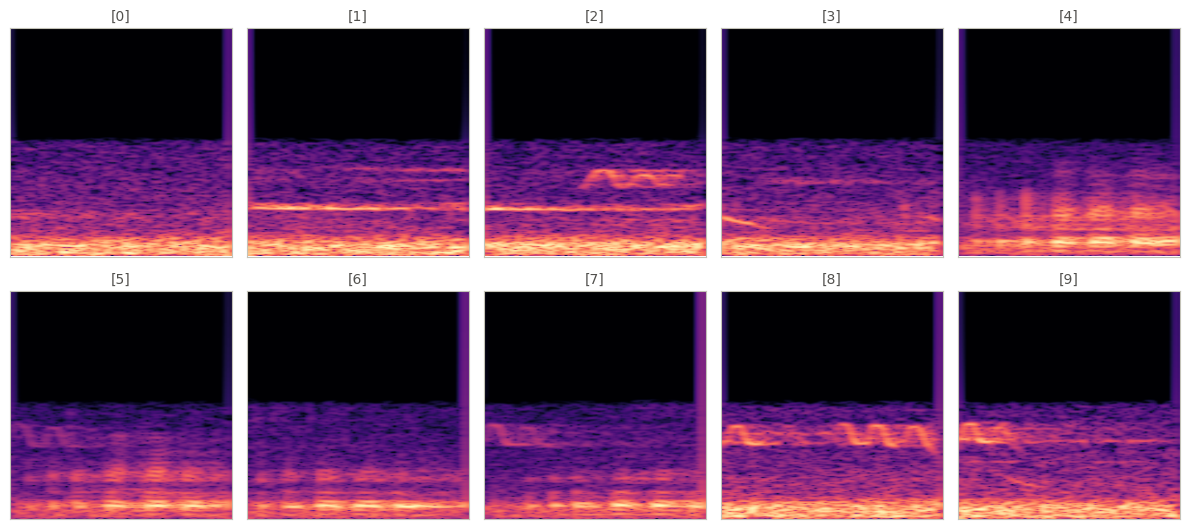

In [255]:
thing = plot_spectrogram_grid(specs_raven)

In [56]:
from probes import run_all

In [60]:
ck = lambda a, b: compute_ck1_distance(a, b)
run_all(specs_raven[4], ck)

shift probe (time axis)
  frames  ~pixels  ms @hop64       CK
       0      0.0        0.0   0.0000
       1      2.9        1.5   0.0856
       2      5.8        2.9   0.1033
       4     11.6        5.8   0.1666
       8     23.3       11.6   0.6821
      16     46.5       23.2   0.7799

blur probe (time axis)
   sigma       CK
     0.0   0.0000
     0.5   0.0399
     1.0   0.2319
     2.0   0.5163
     4.0   0.7323

gain probe
      dB       CK
       0   0.0000
       3   0.0000
       6   0.0000
      12   0.0000


In [62]:
ck = lambda a, b: compute_ck1_distance(a, b)
run_all(specs_raven[4], ck)

In [65]:
_, onset_times = load_and_detect_onsets("../data/xc/XC1089337 - Northern Raven - Corvus corax.wav")

In [66]:
from probes2 import shift_probe_audio, shift_tolerance_ms

audio = es.MonoLoader(filename="../data/xc/XC1089337 - Northern Raven - Corvus corax.wav", sampleRate=44100)()
ck   = lambda a, b: compute_ck1_distance(a, b, target_size=(80, 128))
spec = lambda seg: compute_spectrogram_from_chunk(seg)[:128]

curve = shift_probe_audio(audio, onset_times[4], ck, spec)
print(f"tolerance: {shift_tolerance_ms(curve):.1f} ms")

 shift_ms       CK
        0   0.0000
        1   0.1756
        2   0.2034
        4   0.2076
        6   0.2115
        8   0.2328
       12   0.4296
       16   0.6338
       24   0.6434
       32   0.6452
tolerance: 1.9 ms


In [67]:
ck_old   = lambda a, b: compute_ck1_distance(a, b, target_size=(256, 256))
spec_old = lambda seg: compute_spectrogram_from_chunk(seg)
curve_old = shift_probe_audio(audio, onset_times[4], ck_old, spec_old)

 shift_ms       CK
        0   0.0000
        1   0.1889
        2   0.2105
        4   0.1763
        6   0.1772
        8   0.2786
       12   0.6044
       16   0.8069
       24   0.7994
       32   0.8075


In [68]:
for q in (5, 10, 15, 20, 25, 31):
    ck_q = lambda a, b, q=q: compute_ck1_distance(a, b, target_size=(80,128), quality=q)
    c = shift_probe_audio(audio, onset_times[4], ck_q, spec, verbose=False)
    step = c[1][1]                      # CK at 1 ms
    ceil = c[-1][1]                     # saturation
    print(f"q={q:>2}  step@1ms={step:.3f}  ceiling={ceil:.3f}  ratio={step/ceil:.3f}")

q= 5  step@1ms=0.176  ceiling=0.645  ratio=0.272
q=10  step@1ms=0.153  ceiling=0.662  ratio=0.231
q=15  step@1ms=0.146  ceiling=0.681  ratio=0.215
q=20  step@1ms=0.131  ceiling=0.642  ratio=0.204
q=25  step@1ms=0.076  ceiling=0.524  ratio=0.145
q=31  step@1ms=0.047  ceiling=0.440  ratio=0.108


In [27]:
import itertools, numpy as np
from ck_eval import evaluate

def run_config(paths_labels, target_size, quality, crop=128):
    rows = []
    for name, path, labels in paths_labels:
        _, onset_times = load_and_detect_onsets(path)
        audio = es.MonoLoader(filename=path, sampleRate=44100)()
        win = int(0.125 * 44100)
        specs = []
        for t in onset_times:
            a = int(t * 44100)
            if a + win > len(audio):
                continue
            s = compute_spectrogram_from_chunk(audio[a:a + win])
            if s is not None:
                specs.append(s[:crop])
        n = len(specs)
        m = np.zeros((n, n))
        for i in range(n):
            for j in range(i + 1, n):
                d = compute_ck1_distance(specs[i], specs[j],
                                         target_size=target_size, quality=quality)
                m[i, j] = m[j, i] = d
        rows.append(evaluate(m, labels, name, n_boot=500))
    return rows

sets = [("microwave", mw_path, [[3,5,7,9]]),
        ("raven",     rv_path, [[4,5,6,7]]),
        ("gibbon",     gb_path, [[2,3,5,6]]),
        ("combined",   cb_path, [[4,5,6,7],[11,12,14,15]])]

for q in (5, 15, 20, 25):
    rs = run_config(sets, (80, 128), q)
    print(f"q={q:>2}  meanAUC={np.mean([r['auc'] for r in rs]):.3f}  " +
          "  ".join(f"{r['name'][:4]}={r['auc']:.2f}/medW={r['median_within']:.3f}" for r in rs))

In [26]:
specs_rv[0].shape

(257, 88)

In [72]:
print_iframe_sizes(specs_raven, quality=25, target_size=(80, 128))

 idx   I-frame bytes
   0             356
   1             395
   2             413
   3             365
   4             374
   5             366
   6             357
   7             359
   8             410
   9             400


[356, 395, 413, 365, 374, 366, 357, 359, 410, 400]

In [75]:
from baselines import build_matrix, dumb_energy, dumb_euclidean, measure_overhead
from ck_eval import evaluate

print("stream overhead:", measure_overhead((80, 128), 25), "bytes")

for name, specs, labels in [("microwave", specs_mw, [[3,5,7,9]]),
                            ("raven",     specs_rv, [[4,5,6,7]]),
                            ("gibbon",    specs_gb, [[2,3,5,6]]),
                            ("combined",  specs_cb, [[4,5,6,7],[11,12,14,15]])]:
    ck   = lambda a, b: compute_ck1_distance(a, b, target_size=(80,128), quality=25)
    rows = {
        "CK q=25":   evaluate(build_matrix(specs, ck),             labels, name, n_boot=300),
        "euclidean": evaluate(build_matrix(specs, dumb_euclidean), labels, name, n_boot=300),
        "energy":    evaluate(build_matrix(specs, dumb_energy),    labels, name, n_boot=300),
    }
    print(f"\n{name}")
    for k, r in rows.items():
        print(f"  {k:<12} AUC={r['auc']:.3f}  MAP={r['map']:.3f}  1NN={r['nn1']:.2f}")

stream overhead: 249 bytes

microwave
  CK q=25      AUC=0.969  MAP=1.000  1NN=1.00
  euclidean    AUC=0.946  MAP=1.000  1NN=1.00
  energy       AUC=0.963  MAP=1.000  1NN=1.00

raven
  CK q=25      AUC=0.842  MAP=1.000  1NN=1.00
  euclidean    AUC=0.731  MAP=0.795  1NN=1.00
  energy       AUC=0.615  MAP=0.878  1NN=1.00

gibbon
  CK q=25      AUC=1.000  MAP=1.000  1NN=1.00
  euclidean    AUC=1.000  MAP=1.000  1NN=1.00
  energy       AUC=1.000  MAP=1.000  1NN=1.00

combined
  CK q=25      AUC=0.883  MAP=1.000  1NN=1.00
  euclidean    AUC=0.907  MAP=0.898  1NN=1.00
  energy       AUC=0.826  MAP=0.853  1NN=0.88


In [35]:
for name, path, labels in sets:
    m, times, specs = analyze_recording_onsets_ck(path, window_ms=125)
    r = evaluate(m, labels, name, n_boot=300)
    print(f"{name:<10} AUC={r['auc']:.3f}  medW={r['median_within']:.3f}")

Processing: 232929_4211564-hq.ogg
Filtered Onsets to process: 11
Successfully generated 11 onset spectrograms.
microwave  AUC=1.000  medW=0.442
Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfully generated 10 onset spectrograms.
raven      AUC=0.795  medW=1.237
Processing: XC1155322 - Lar Gibbon - Hylobates lar.wav
Filtered Onsets to process: 7
Successfully generated 7 onset spectrograms.
gibbon     AUC=1.000  medW=0.976
Processing: combined.wav
Filtered Onsets to process: 16
Successfully generated 16 onset spectrograms.
combined   AUC=0.897  medW=1.152


In [30]:
import numpy as np
from ck_eval import evaluate

def run(**kw):
    out = []
    for name, path, labels in sets:
        m, _, specs = analyze_recording_onsets_ck(path, window_ms=125)
        out.append(evaluate(m, labels, name, n_boot=200))
    return np.mean([r['auc'] for r in out]), out

In [31]:
sets

[('microwave',
  '../data/audio/microwave-beeps/232929_4211564-hq.ogg',
  [[3, 5, 7, 9]]),
 ('raven',
  '../data/xc/XC1089337 - Northern Raven - Corvus corax.wav',
  [[4, 5, 6, 7]]),
 ('gibbon',
  '../data/xc/XC1155322 - Lar Gibbon - Hylobates lar.wav',
  [[2, 3, 5, 6]]),
 ('combined', '../data/xc/combined.wav', [[4, 5, 6, 7], [11, 12, 14, 15]])]

In [28]:
for so in (True, False):
    print(f"\n=== subtract_overhead={so} ===")
    aucs = []
    for name, path, labels in sets:
        m, times, specs = analyze_recording_onsets_ck(path, window_ms=125,
                                                      subtract_overhead=so)
        r = evaluate(m, labels, name, n_boot=300)
        aucs.append(r['auc'])
        print(f"{name:<10} AUC={r['auc']:.3f}  medW={r['median_within']:.3f}  "
              f"medB={r['median_between']:.3f}")
    print(f"{'MEAN':<10} AUC={np.mean(aucs):.3f}")


=== subtract_overhead=True ===
Processing: 232929_4211564-hq.ogg
Filtered Onsets to process: 11
Successfully generated 11 onset spectrograms.
microwave  AUC=1.000  medW=0.442  medB=1.275
Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfully generated 10 onset spectrograms.
raven      AUC=0.795  medW=1.237  medB=1.355
Processing: XC1155322 - Lar Gibbon - Hylobates lar.wav
Filtered Onsets to process: 7
Successfully generated 7 onset spectrograms.
gibbon     AUC=1.000  medW=0.976  medB=1.171
Processing: combined.wav
Filtered Onsets to process: 16
Successfully generated 16 onset spectrograms.
combined   AUC=0.897  medW=1.152  medB=1.401
MEAN       AUC=0.923

=== subtract_overhead=False ===
Processing: 232929_4211564-hq.ogg
Filtered Onsets to process: 11
Successfully generated 11 onset spectrograms.
microwave  AUC=1.000  medW=0.303  medB=0.792
Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfull

In [29]:
for q in (5, 10, 15, 20, 25):
    aucs = []
    for name, path, labels in sets:
        m, _, _ = analyze_recording_onsets_ck(path, window_ms=125, quality=q)   # pass q through
        r = evaluate(m, labels, name, n_boot=200)
        aucs.append(r['auc'])
    print(f"q={q:>2}  meanAUC={np.mean(aucs):.3f}")

Processing: 232929_4211564-hq.ogg
Filtered Onsets to process: 11
Successfully generated 11 onset spectrograms.
Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfully generated 10 onset spectrograms.
Processing: XC1155322 - Lar Gibbon - Hylobates lar.wav
Filtered Onsets to process: 7
Successfully generated 7 onset spectrograms.
Processing: combined.wav
Filtered Onsets to process: 16
Successfully generated 16 onset spectrograms.
q= 5  meanAUC=0.306
Processing: 232929_4211564-hq.ogg
Filtered Onsets to process: 11
Successfully generated 11 onset spectrograms.
Processing: XC1089337 - Northern Raven - Corvus corax.wav
Filtered Onsets to process: 10
Successfully generated 10 onset spectrograms.
Processing: XC1155322 - Lar Gibbon - Hylobates lar.wav
Filtered Onsets to process: 7
Successfully generated 7 onset spectrograms.
Processing: combined.wav
Filtered Onsets to process: 16
Successfully generated 16 onset spectrograms.
q=10  meanAUC=0.417
Proc

### Tune method on Freesound subset

In [152]:
# ONE TIME RUN
fsids = []
with open("../data/ck_mini", "r") as f:
    fsids = f.readlines()
fsids = [int(fsid.strip()) for fsid in fsids]
random.shuffle(fsids)
# END ONE TIME RUN

In [154]:
with open("../data/ck_mini.json", "w") as f:
    json.dump(fsids, f)

In [168]:
i = 682768
df.loc[list(df["sound_id"]).index(i)]["local_path"]
annotations[str(i)]["repetitive_onset_indices"]

[3, 4, 5]

In [169]:
fpath_annotations = {}
for fsid in fsids:
    fpath_annotations[fsid] = (df.loc[list(df["sound_id"]).index(fsid)]["local_path"],
                               annotations[str(fsid)]["repetitive_onset_indices"])

In [170]:
fpath_annotations

{59592: ('../data/audio/high-heels/59592_27178-hq.ogg', [3, 4, 6, 7, 9]),
 263048: ('../data/audio/fingers-snapping/263048_4936834-hq.ogg',
  [5, 7, 9, 10, 11]),
 468527: ('../data/audio/"3-times"/468527_9786444-hq.ogg', [4, 5, 6]),
 764830: ('../data/audio/fingers-snapping/764830_15688679-hq.ogg',
  [5, 6, 7, 8, 10, 11]),
 171544: ('../data/audio/bouncing-ball/171544_670687-hq.ogg', [1, 5, 9, 13]),
 419928: ('../data/audio/chopping-wood/419928_8373708-hq.ogg', [1, 9, 10, 11]),
 682768: ('../data/audio/car-engine/682768_14662423-hq.ogg', [3, 4, 5]),
 334428: ('../data/audio/boxing-hits/334428_2972303-hq.ogg', [1, 4, 5]),
 49597: ('../data/audio/bell/49597_215874-hq.ogg', [2, 3, 6]),
 172356: ('../data/audio/high-heels/172356_1467893-hq.ogg', [1, 4, 6, 8, 10]),
 832873: ('../data/audio/mouth-popping/832873_18115820-hq.ogg',
  [6, 8, 10, 11]),
 408464: ('../data/audio/clock-ticking/408464_7118587-hq.ogg', [1, 8, 13]),
 153294: ('../data/audio/lighter/153294_2358240-hq.ogg', [0, 3]),
 326

In [173]:
from run_corpus import run_corpus, report_all, log_experiment, show_log, compare_to, CONFIG

results = run_corpus(fpath_annotations)
summaries = report_all(results, split_at=10)
log_experiment("baseline", CONFIG, results, summaries)

[1/20] high-heels/59592
[2/20] fingers-snapping/263048
[3/20] "3-times"/468527
[4/20] fingers-snapping/764830
[5/20] bouncing-ball/171544
[6/20] chopping-wood/419928
[7/20] car-engine/682768
[8/20] boxing-hits/334428
[9/20] bell/49597
[10/20] high-heels/172356
[11/20] mouth-popping/832873
[12/20] clock-ticking/408464
[13/20] lighter/153294
[14/20] fingers-snapping/326937
[15/20] dog-bark/475359
[16/20] "3-times"/740073
[17/20] clock-ticking/627144
[18/20] clock-ticking/707982
[19/20] "3-times"/577815
[20/20] hammering/239460

done in 484s

CK
recording                       AUC      d     F1    thr   medW   medB
----------------------------------------------------------------------
lighter/153294                0.000  -3.31   0.18  0.755  0.755  0.634
clock-ticking/408464          0.060  -1.64   0.04  0.751  0.722  0.560
hammering/239460              0.250  -1.04   0.02  0.672  0.672  0.507
clock-ticking/627144          0.293  -0.78   0.20  0.809  0.755  0.711
"3-times"/740073         

1

In [195]:
fpath_annotations

{59592: ('../data/audio/high-heels/59592_27178-hq.ogg', [3, 4, 6, 7, 9]),
 263048: ('../data/audio/fingers-snapping/263048_4936834-hq.ogg',
  [5, 7, 9, 10, 11]),
 468527: ('../data/audio/"3-times"/468527_9786444-hq.ogg', [4, 5, 6]),
 764830: ('../data/audio/fingers-snapping/764830_15688679-hq.ogg',
  [5, 6, 7, 8, 10, 11]),
 171544: ('../data/audio/bouncing-ball/171544_670687-hq.ogg', [1, 5, 9, 13]),
 419928: ('../data/audio/chopping-wood/419928_8373708-hq.ogg', [1, 9, 10, 11]),
 682768: ('../data/audio/car-engine/682768_14662423-hq.ogg', [3, 4, 5]),
 334428: ('../data/audio/boxing-hits/334428_2972303-hq.ogg', [1, 4, 5]),
 49597: ('../data/audio/bell/49597_215874-hq.ogg', [2, 3, 6]),
 172356: ('../data/audio/high-heels/172356_1467893-hq.ogg', [1, 4, 6, 8, 10]),
 832873: ('../data/audio/mouth-popping/832873_18115820-hq.ogg',
  [6, 8, 10, 11]),
 408464: ('../data/audio/clock-ticking/408464_7118587-hq.ogg', [1, 8, 13]),
 153294: ('../data/audio/lighter/153294_2358240-hq.ogg', [0, 3]),
 326

#### Actual improvement loop

In [236]:
from run_corpus import run_corpus, report_all, log_experiment, show_log, CONFIG

tune = dict(list(fpath_annotations.items())[:10])

grid = []
for log_freq in (False, True):
    for size, hop in [((80,128), 64), ((128,128), 44), ((128,80), 44)]:
        grid.append(dict(CONFIG, log_freq=log_freq,
                         target_size=size, hop_size=hop, crop=size[1]))

for cfg in grid:
    label = f"{'mel' if cfg['log_freq'] else 'lin'}_{cfg['target_size'][0]}x{cfg['target_size'][1]}"
    print(f"\n### {label}")
    results = run_corpus(tune, config=cfg, verbose=False)
    summaries = report_all(results, split_at=None, verbose=False)
    log_experiment(label, cfg, results, summaries)

show_log()


### lin_80x128


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.823    0.817  +0.006    0.62    0.13   2.38
euclidean       0.840    0.787  +0.053    0.56    0.22   1.54
energy          0.743    0.751  -0.007    0.40    0.62   1.22
logged 'lin_80x128' (entry 2)

### lin_128x128


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.799    0.794  +0.005    0.64    0.11   2.14
euclidean       0.863    0.793  +0.070    0.62    0.23   1.54
energy          0.745    0.751  -0.007    0.40    0.61   1.23
logged 'lin_128x128' (entry 3)

### lin_128x80


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.800    0.812  -0.012    0.63    0.12   1.92
euclidean       0.861    0.788  +0.072    0.63    0.21   1.85
energy          0.757    0.777  -0.020    0.44    0.51   1.28
logged 'lin_128x80' (entry 4)

### mel_80x128


RuntimeError: Error while configuring MelBands: TriangularBands: the number of spectrum bins is insufficient for the specified number of triangular bands. Use zero padding to increase the number of FFT bins.

In [241]:
tune = dict(list(fpath_annotations.items())[:10])

grid = []
for log_freq in (True,):
    for size, hop in [((80,128), 64), ((128,128), 44), ((128,80), 44)]:
        grid.append(dict(CONFIG, log_freq=log_freq,
                         target_size=size, hop_size=hop, crop=size[1]))

for cfg in grid:
    label = f"{'log' if cfg['log_freq'] else 'lin'}_{cfg['target_size'][0]}x{cfg['target_size'][1]}"
    print(f"\n### {label}")
    results = run_corpus(tune, config=cfg, verbose=False)
    summaries = report_all(results, split_at=None, verbose=False)
    log_experiment(label, cfg, results, summaries)


### log_80x128


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.892    0.849  +0.043    0.71    0.15   2.80
euclidean       0.857    0.777  +0.081    0.60    0.23   1.75
energy          0.770    0.760  +0.011    0.40    0.48   1.28
logged 'log_80x128' (entry 5)

### log_128x128


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.870    0.830  +0.040    0.69    0.11   2.49
euclidean       0.846    0.767  +0.080    0.60    0.24   1.64
energy          0.773    0.761  +0.012    0.40    0.63   1.29
logged 'log_128x128' (entry 6)

### log_128x80


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.858    0.852  +0.006    0.67    0.11   2.13
euclidean       0.846    0.766  +0.081    0.59    0.21   1.60
energy          0.770    0.760  +0.010    0.40    0.54   1.28
logged 'log_128x80' (entry 7)


(257, 88) (128, 88)


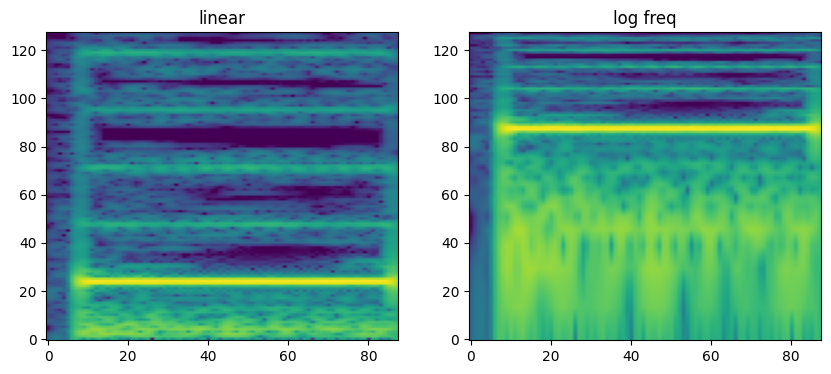

In [240]:
seg = es.MonoLoader(filename=mw_path, sampleRate=44100)()[:5512]
a = compute_spectrogram_from_chunk(seg, log_freq=False)
b = compute_spectrogram_from_chunk(seg, log_freq=True, n_bands=128)
print(a.shape, b.shape)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(a[:128], origin='lower', aspect='auto'); ax[0].set_title('linear')
ax[1].imshow(b, origin='lower', aspect='auto'); ax[1].set_title('log freq')
plt.show()

In [263]:
grid_lin = []
for log_freq in (False,):
    for size, hop in [((80,128), 64), ((128,128), 44), ((128,80), 44)]:
        grid_lin.append(dict(CONFIG, log_freq=log_freq,
                         target_size=size, hop_size=hop, crop=size[1]))

In [264]:
grid_lin

[{'window_ms': 125,
  'target_size': (80, 128),
  'quality': 25,
  'subtract_overhead': False,
  'crop': 128,
  'sr': 44100,
  'log_freq': False,
  'hop_size': 64},
 {'window_ms': 125,
  'target_size': (128, 128),
  'quality': 25,
  'subtract_overhead': False,
  'crop': 128,
  'sr': 44100,
  'log_freq': False,
  'hop_size': 44},
 {'window_ms': 125,
  'target_size': (128, 80),
  'quality': 25,
  'subtract_overhead': False,
  'crop': 80,
  'sr': 44100,
  'log_freq': False,
  'hop_size': 44}]

In [265]:
grid_log = []
for log_freq in (True,):
    for size, hop in [((80,128), 64), ((128,128), 44), ((128,80), 44)]:
        grid_log.append(dict(CONFIG, log_freq=log_freq,
                         target_size=size, hop_size=hop, crop=size[1]))

In [266]:
grid_log

[{'window_ms': 125,
  'target_size': (80, 128),
  'quality': 25,
  'subtract_overhead': False,
  'crop': 128,
  'sr': 44100,
  'log_freq': True,
  'hop_size': 64},
 {'window_ms': 125,
  'target_size': (128, 128),
  'quality': 25,
  'subtract_overhead': False,
  'crop': 128,
  'sr': 44100,
  'log_freq': True,
  'hop_size': 44},
 {'window_ms': 125,
  'target_size': (128, 80),
  'quality': 25,
  'subtract_overhead': False,
  'crop': 80,
  'sr': 44100,
  'log_freq': True,
  'hop_size': 44}]

In [267]:
hold = dict(list(fpath_annotations.items())[10:])
for cfg, tag in [(grid_lin[0], "lin_80x128"), (grid_log[0], "log_80x128"), (grid_log[2], "log_128x80")]:
    print(f"\n### HOLDOUT {tag}")
    results = run_corpus(hold, config=cfg, verbose=False)
    report_all(results, split_at=None, verbose=False)


### HOLDOUT lin_80x128


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.517    0.433  +0.084    0.37    0.11  -0.01
euclidean       0.570    0.533  +0.037    0.40    0.28   0.36
energy          0.644    0.646  -0.002    0.35    0.69   0.99

### HOLDOUT log_80x128


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.539    0.503  +0.035    0.42    0.10   0.29
euclidean       0.575    0.520  +0.056    0.43    0.23   0.37
energy          0.725    0.712  +0.013    0.36    0.36   1.16

### HOLDOUT log_128x80


SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.518    0.448  +0.070    0.41    0.09  -0.02
euclidean       0.565    0.505  +0.060    0.42    0.23   0.28
energy          0.730    0.709  +0.021    0.37    0.41   1.13


In [268]:
cfg = dict(CONFIG, log_freq=True, target_size=(128,128), hop_size=44, crop=128)
results = run_corpus(hold, config=cfg, verbose=False)
report_all(results, split_at=None, verbose=False)



SUMMARY -- all recordings
method        meanAUC  poolAUC     gap  meanF1   thrCV      d
CK              0.531    0.470  +0.060    0.39    0.08   0.01
euclidean       0.571    0.511  +0.059    0.42    0.24   0.37
energy          0.732    0.711  +0.021    0.37    0.40   1.14


{'CK': {'n_recordings': 10,
  'mean_auc': 0.5306076555719413,
  'pooled_auc': np.float64(0.47042970874746576),
  'calibration_gap': np.float64(0.06017794682447558),
  'mean_cohens_d': 0.005216873562146706,
  'mean_best_f1': 0.3942818968304261,
  'threshold_mean': 0.7484302400371348,
  'threshold_sd': 0.06130931637398013,
  'threshold_cv': 0.08191720897185842},
 'euclidean': {'n_recordings': 10,
  'mean_auc': 0.5706511715797429,
  'pooled_auc': np.float64(0.5112248430005439),
  'calibration_gap': np.float64(0.05942632857919894),
  'mean_cohens_d': 0.36525651272499465,
  'mean_best_f1': 0.41892052982478517,
  'threshold_mean': 5.925988276464116,
  'threshold_sd': 1.4270436708632388,
  'threshold_cv': 0.24081108572741203},
 'energy': {'n_recordings': 10,
  'mean_auc': 0.7315609179180608,
  'pooled_auc': np.float64(0.7108490332789398),
  'calibration_gap': np.float64(0.020711884639120992),
  'mean_cohens_d': 1.13522442114892,
  'mean_best_f1': 0.36756129491423606,
  'threshold_mean': 2.589

### Garbage

##### Sliding window experiments

In [44]:
def compute_sliding_distance_profile(file_path, template_onset_index, window_ms=125, target_sr=44100):
    """
    Takes a specific onset as a template and slides a window across the 
    entire global spectrogram to compute a compression distance profile.
    """
    # 1. Run your standard onset extraction to get the list of chunks
    ck_matrix, valid_onset_times, onset_spectrograms = analyze_recording_onsets_ck(file_path, window_ms, target_sr)
    
    if template_onset_index >= len(onset_spectrograms):
        print(f"Index {template_onset_index} out of range!")
        return None

    template_chunk = onset_spectrograms[template_onset_index]

    # 2. Re-extract the global spectrogram to slide across
    _, _, audio_high = load_and_detect_onsets(file_path, return_hq_audio=True, high_sr=target_sr)
    windowing = es.Windowing(type='hann')
    spectrum = es.Spectrum()
    
    spec_list = []
    hop_size = 64
    for frame in es.FrameGenerator(audio_high, frameSize=512, hopSize=hop_size):
        spec_list.append(spectrum(windowing(frame)))
        
    global_spectrogram = np.array(spec_list).T
    global_spectrogram_db = 20 * np.log10(np.maximum(global_spectrogram, 1e-5))
    global_max_db = np.max(global_spectrogram_db)

    samples_per_window = int((window_ms / 1000.0) * target_sr)
    frames_per_window = int(samples_per_window / hop_size)

    # 3. Slide window step-by-step across the entire file
    profile_distances = []
    profile_timestamps = []

    max_start_frame = global_spectrogram_db.shape[1] - frames_per_window
    for start_frame in range(0, max_start_frame, frames_per_window // 4): # 75% overlap sliding
        end_frame = start_frame + frames_per_window
        
        spec_chunk = global_spectrogram_db[:, start_frame:end_frame]
        candidate_chunk = preprocess_spectrogram(spec_chunk, global_max_db)
        
        # Compute CK-1 distance between our template and this sliding window
        dist = compute_ck1_distance(template_chunk, candidate_chunk)
        
        profile_distances.append(dist)
        profile_timestamps.append((start_frame * hop_size) / target_sr)

    return np.array(profile_timestamps), np.array(profile_distances)

In [48]:
tstamps, dists = compute_sliding_distance_profile(file_path, 4, window_ms=125, target_sr=44100)

Computing global high-density spectrogram...


In [49]:
tstamps

array([ 0.        ,  0.03047619,  0.06095238,  0.09142857,  0.12190476,
        0.15238095,  0.18285714,  0.21333333,  0.24380952,  0.27428571,
        0.3047619 ,  0.3352381 ,  0.36571429,  0.39619048,  0.42666667,
        0.45714286,  0.48761905,  0.51809524,  0.54857143,  0.57904762,
        0.60952381,  0.64      ,  0.67047619,  0.70095238,  0.73142857,
        0.76190476,  0.79238095,  0.82285714,  0.85333333,  0.88380952,
        0.91428571,  0.9447619 ,  0.9752381 ,  1.00571429,  1.03619048,
        1.06666667,  1.09714286,  1.12761905,  1.15809524,  1.18857143,
        1.21904762,  1.24952381,  1.28      ,  1.31047619,  1.34095238,
        1.37142857,  1.40190476,  1.43238095,  1.46285714,  1.49333333,
        1.52380952,  1.55428571,  1.5847619 ,  1.6152381 ,  1.64571429,
        1.67619048,  1.70666667,  1.73714286,  1.76761905,  1.79809524,
        1.82857143,  1.85904762,  1.88952381,  1.92      ,  1.95047619,
        1.98095238,  2.01142857,  2.04190476,  2.07238095,  2.10

In [50]:
dists

array([0.66383039, 0.66513013, 0.66575014, 0.65225878, 0.66432486,
       0.66049993, 0.6523338 , 0.66040834, 0.67437887, 0.67279359,
       0.68148254, 0.67330706, 0.66440363, 0.65433592, 0.65547829,
       0.67734182, 0.66372618, 0.66523242, 0.65928017, 0.65556103,
       0.65537849, 0.65579223, 0.67164179, 0.6633615 , 0.68184354,
       0.66510849, 0.66454278, 0.65379485, 0.65380553, 0.66577333,
       0.67124542, 0.65604472, 0.66676021, 0.67135622, 0.66596462,
       0.66090332, 0.66236149, 0.67219505, 0.67121148, 0.66906831,
       0.67605734, 0.68614063, 0.66931604, 0.67420465, 0.66741779,
       0.68147622, 0.66877397, 0.65523555, 0.67279699, 0.68991087,
       0.68066805, 0.67714388, 0.67159148, 0.67651035, 0.6876622 ,
       0.68393638, 0.67889273, 0.673015  , 0.67086318, 0.66012021,
       0.67523864, 0.67339898, 0.66377705, 0.67207955, 0.67397182,
       0.66535044, 0.67383158, 0.67125914, 0.6658442 , 0.6753734 ,
       0.66758436, 0.67969797, 0.67576165, 0.67859674, 0.66492

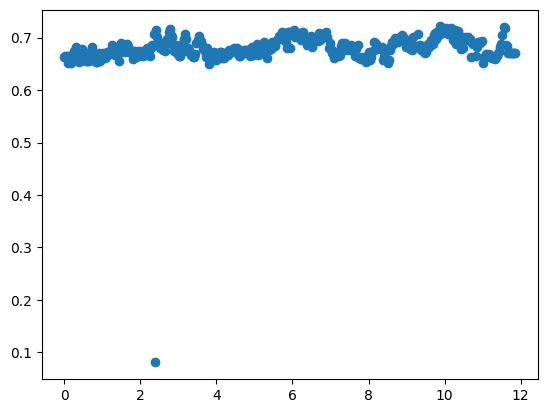

In [51]:
plt.scatter(tstamps, dists)

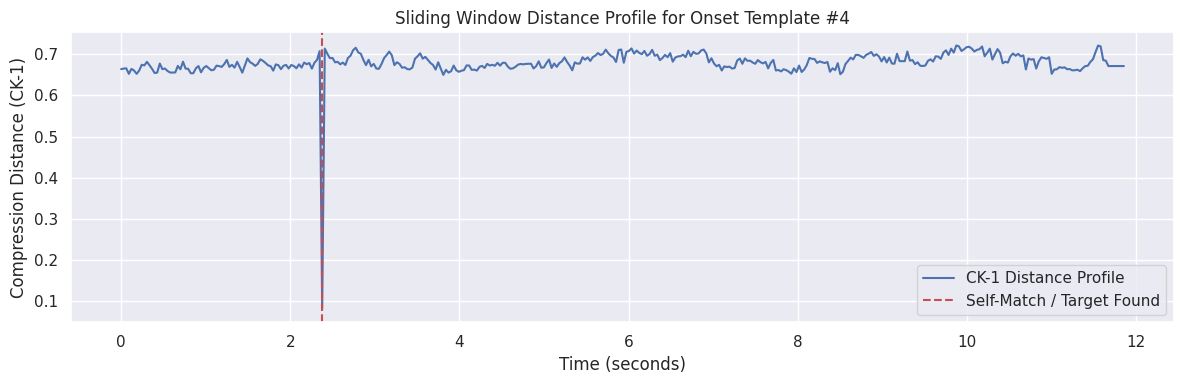

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot style
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 4))

plt.plot(tstamps, dists, color='b', lw=1.5, label='CK-1 Distance Profile')
plt.axvline(x=2.37, color='r', linestyle='--', label='Self-Match / Target Found')

plt.xlabel('Time (seconds)')
plt.ylabel('Compression Distance (CK-1)')
plt.title('Sliding Window Distance Profile for Onset Template #4')
plt.legend()
plt.tight_layout()
plt.show()